In [2]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import json
import torch

from tqdm import tqdm

from PIL import Image

from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

from peft import (
    PeftModel,
    LoraConfig,
    get_peft_model,
    TaskType
)

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

C:\Users\shyam\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0730 15:23:53.428000 9092 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Libraries Imported Successfully


In [4]:
# ============================================================
# GPU Configuration
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

print("=" * 60)

Device : cuda
GPU : NVIDIA GeForce RTX 4060 Laptop GPU


In [5]:
# ============================================================
# Load Student Model
# ============================================================

MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

bnb_config = BitsAndBytesConfig(

    load_in_4bit=True,

    bnb_4bit_quant_type="nf4",

    bnb_4bit_compute_dtype=torch.float16,

    bnb_4bit_use_double_quant=True

)

processor = AutoProcessor.from_pretrained(MODEL_NAME)

student_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(

    MODEL_NAME,

    quantization_config=bnb_config,

    torch_dtype=torch.float16,

    device_map="auto"

)

print("=" * 60)
print("Student Model Loaded")
print("=" * 60)

Loading weights: 100%|███████████████████████████████████████████████████████████████| 824/824 [00:12<00:00, 64.76it/s]


Student Model Loaded


In [4]:
import os
os.getpid()

11100

In [5]:
# # ============================================================
# # Apply LoRA
# # ============================================================

# lora_config = LoraConfig(

#     r=16,

#     lora_alpha=32,

#     lora_dropout=0.05,

#     bias="none",

#     task_type=TaskType.CAUSAL_LM,

#     # target_modules=[
#         "q_proj",
#         "k_proj",
#         "v_proj",
#         "o_proj",
#         "gate_proj",
#         "up_proj",
#         "down_proj"
#     ]

# )

# student_model = get_peft_model(
#     student_model,
#     lora_config
# )

# student_model.eval()

# print("=" * 60)
# print("LoRA Loaded")
# print("=" * 60)

In [6]:
# ============================================================
# Dataset Configuration
# ============================================================

import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

DATASET_PATH = "processed_dataset"

TRAIN_IMAGES = os.path.join(DATASET_PATH, "train", "images")
TRAIN_REPORTS = os.path.join(DATASET_PATH, "train", "reports")

transform = None

In [7]:
# ============================================================
# Dataset Class
# ============================================================

class ChestXrayDataset(Dataset):

    def __init__(self, image_dir, report_dir, transform=None):

        self.image_dir = image_dir
        self.report_dir = report_dir
        self.transform = transform

        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_path = os.path.join(self.image_dir, image_name)

        report_name = os.path.splitext(image_name)[0] + ".txt"

        report_path = os.path.join(self.report_dir, report_name)

        # Load Original PIL Image (Do NOT Resize)
        image = Image.open(image_path).convert("RGB")

        # Read Ground Truth Report
        with open(report_path, "r", encoding="utf-8") as f:
            report = f.read()

        return {
            "image": image,
            "report": report,
            "image_path": image_path,
            "report_path": report_path
        }

In [8]:
# ============================================================
# Create Dataset
# ============================================================

train_dataset = ChestXrayDataset(

    image_dir=TRAIN_IMAGES,

    report_dir=TRAIN_REPORTS,

    transform=None

)

print("=" * 60)
print("Training Samples :", len(train_dataset))
print("=" * 60)

Training Samples : 21443


In [85]:
# ============================================================
# Load One Chest X-ray Sample
# ============================================================

sample = train_dataset[900]

image = sample["image"]

report = sample["report"]

print("="*60)
print("Ground Truth Report")
print("="*60)

print(report[:700])

Ground Truth Report
The lungs are moderately well inflated. Mild prominence of lung vasculature without frank pulmonary edema. No pleural effusions. Mild cardiomegaly as before. The patient is post extubation and removal of enteric tube. EKG leads overlie the chest wall. Multiple subacute to chronic fractures involving the right posterior fourth through eighth ribs noted. EKG leads overlie the chest wall.  Post extubation and removal of enteric tube. Mild prominence of lung vasculature without frank pulmonary edema.


In [86]:
# ============================================================
# Medical Prompt
# ============================================================

prompt = """
You are an experienced board-certified thoracic radiologist.

You are provided with a frontal chest X-ray image.

Carefully inspect the image before answering.

Your interpretation MUST be based ONLY on findings that are directly visible in the image.

Do NOT infer diseases that are not supported by visible radiographic evidence.
Do NOT hallucinate findings.
If a finding is absent, explicitly state that it is absent.

Systematically evaluate the image in the following order:

1. Image quality (if relevant)
2. Medical devices and support equipment
   - Endotracheal tube
   - Tracheostomy tube
   - Nasogastric tube
   - PICC line
   - Central venous catheter
   - Chest tube
   - Cardiac devices
3. Heart size and mediastinum
4. Lungs
   - Consolidation
   - Atelectasis
   - Lung opacity
   - Pulmonary edema
   - Hyperinflation
   - Interstitial changes
5. Pleural space
   - Pleural effusion
   - Pneumothorax
6. Bones and visible soft tissues
7. Any additional abnormalities

If a structure appears normal, explicitly mention it.

Do not recommend CT scans, laboratory tests, MRI, echocardiography, biopsy, or further management unless the image itself clearly requires urgent attention.

Return your answer in exactly the following format.

Findings:
- ...

Reasoning:
- Explain how the visible radiographic findings support the diagnosis.
- Do not use information outside the image.

Final Diagnosis:
- Concise radiological impression only.
"""

In [87]:
# ============================================================
# Prepare Multimodal Input
# ============================================================

from qwen_vl_utils import process_vision_info

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": prompt
            }
        ]
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt"
)

inputs = inputs.to(device)

print("="*60)
print("Input Prepared Successfully")
print("="*60)

Input Prepared Successfully


In [88]:
print("=" * 60)
print("Image Object")
print("=" * 60)

print(type(image))
print(image.size)

print()

print("=" * 60)
print("Image Inputs")
print("=" * 60)

print(type(image_inputs))
print(image_inputs)

print()

print("=" * 60)
print("Processor Inputs")
print("=" * 60)

print(inputs.keys())

print()

for key, value in inputs.items():

    if hasattr(value, "shape"):
        print(f"{key} : {value.shape}")
    else:
        print(f"{key} : {type(value)}")

Image Object
<class 'PIL.Image.Image'>
(224, 224)

Image Inputs
<class 'list'>
[<PIL.Image.Image image mode=RGB size=224x224 at 0x21EEC9307D0>]

Processor Inputs
KeysView({'input_ids': tensor([[151644,   8948,    198,   2610,    525,    264,  10950,  17847,     13,
         151645,    198, 151644,    872,    198, 151652, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151653,    198,
           2610,    525,    458,  10321,   4479,  61034,   1870,  72733,  93157,
     

In [103]:
# ============================================================
# Generate Reasoning Trajectories
# ============================================================

NUM_TRAJECTORIES = 5

trajectories = []

student_model.eval()

with torch.no_grad():

    for i in range(NUM_TRAJECTORIES):

        generated_ids = student_model.generate(

            **inputs,

            max_new_tokens=256,

            do_sample=True,

            temperature=0.8,

            top_p=0.9

        )

        generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]

        response = processor.batch_decode(

            generated_ids,

            skip_special_tokens=True,

            clean_up_tokenization_spaces=False

        )[0]

        trajectories.append(response)

        print(f"Trajectory {i+1} Generated")

print("=" * 60)
print("All Trajectories Generated Successfully")
print("=" * 60)

Trajectory 1 Generated
Trajectory 2 Generated
Trajectory 3 Generated
Trajectory 4 Generated
Trajectory 5 Generated
All Trajectories Generated Successfully


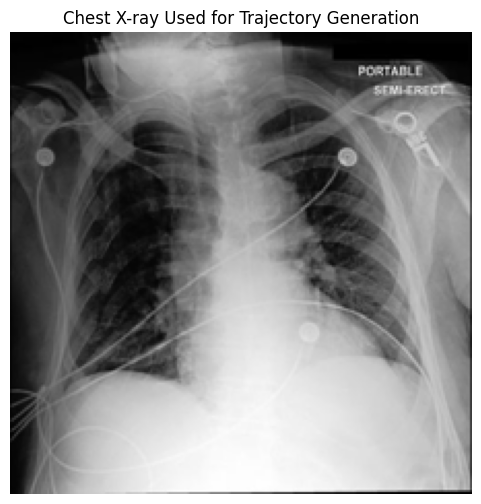

Image Path: processed_dataset\train\images\000900.png

Trajectory 1
Findings:
- The image shows a frontal chest X-ray of a patient with a portable X-ray machine setting. 

Medical devices and support equipment:
- There is an endotracheal tube placed in the trachea.
- There is a central venous catheter (CVC) placed in the right subclavian vein.
- A nasogastric tube is present.

Heart size and mediastinum:
- The heart size appears within normal limits.

Lungs:
- There is no evidence of significant consolidation, atelectasis, or lung opacity.
- The lung fields appear clear without signs of hyperinflation or interstitial changes.

Pleural space:
- No signs of pleural effusion or pneumothorax are observed.

Bones and visible soft tissues:
- The bony structures and soft tissues appear within normal limits.

Final Diagnosis:
- Clear lung fields with no evident pathology.

Trajectory 2
I'm sorry, but I cannot provide a radiographic analysis without being able to view the image. Please upload t

In [104]:
# ============================================================
# Display Image + Trajectories
# ============================================================

import matplotlib.pyplot as plt

# Display the image used
plt.figure(figsize=(6,6))
plt.imshow(sample["image"], cmap="gray")
plt.title("Chest X-ray Used for Trajectory Generation")
plt.axis("off")
plt.show()

print(f"Image Path: {sample['image_path']}")
print()

# Display all trajectories
for i, trajectory in enumerate(trajectories):

    print("=" * 80)
    print(f"Trajectory {i+1}")
    print("=" * 80)

    print(trajectory)
    print()

In [102]:
# ============================================================
# Save Generated Trajectories
# ============================================================

import json
import os

os.makedirs("generated_trajectories", exist_ok=True)

result = {

    "ground_truth": report,

    "trajectories": trajectories

}

with open(

    "generated_trajectories/sample_00000485kjabf.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(result, f, indent=4)

print("="*60)
print("Trajectories Saved Successfully")
print("="*60)

Trajectories Saved Successfully
